In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
datos = load_breast_cancer(as_frame=True)
X = datos.data
y = datos.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print(X.shape)
print(y.value_counts(normalize=True))

(569, 30)
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


positiva_perfecta Pearson = 1.0 Spearman = 1.0
negativa_perfecta Pearson = -1.0 Spearman = -1.0
curva_en_U Pearson = 0.308 Spearman = 0.089
monotona_curva Pearson = 0.969 Spearman = 1.0


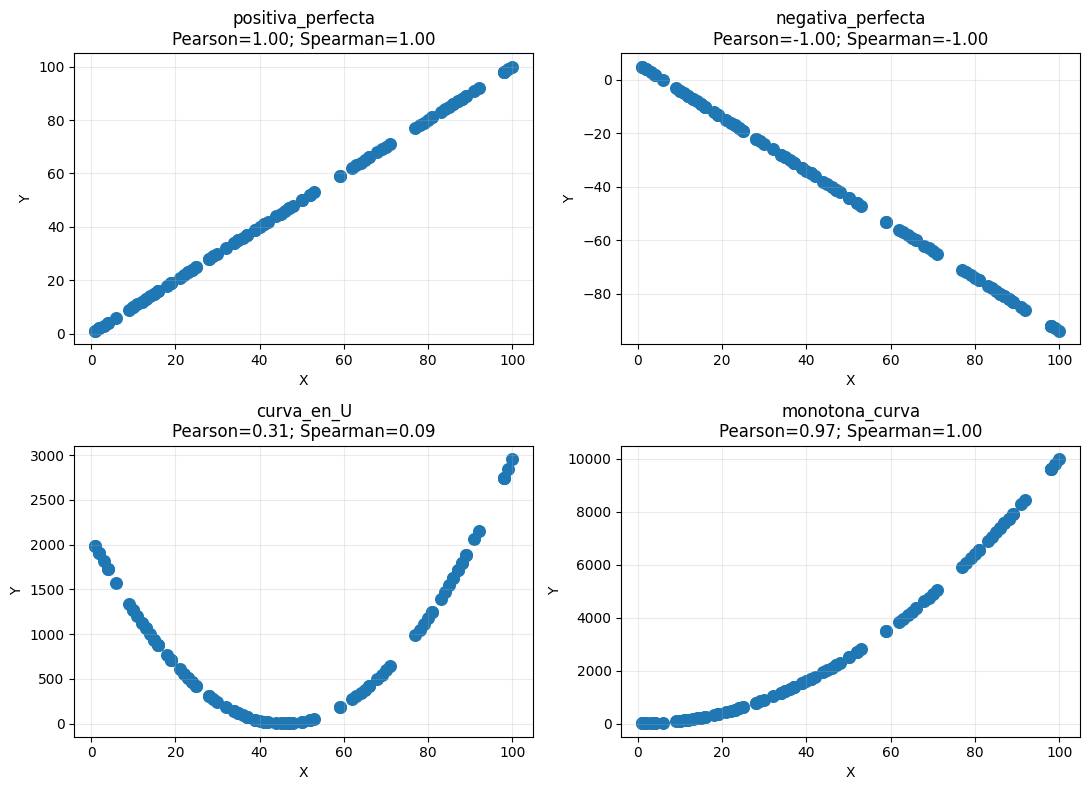

In [8]:
x = np.random.randint(1, 101, size=100)

mean = np.mean(x)

ejemplos_correlacion = pd.DataFrame({
    "positiva_perfecta": x,
    "negativa_perfecta": 6 - x,
    "curva_en_U": (x - mean) ** 2,
    "monotona_curva": x ** 2,
})

for nombre in ejemplos_correlacion:
    z = ejemplos_correlacion[nombre]
    print(
        nombre,
        "Pearson =", round(pd.Series(x).corr(pd.Series(z)), 3),
        "Spearman =", round(pd.Series(x).corr(pd.Series(z), method="spearman"), 3),
    )

# Cada panel muestra la forma de la relación y los dos coeficientes.
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (nombre, z) in zip(axes.ravel(), ejemplos_correlacion.items()):
    pearson = pd.Series(x).corr(pd.Series(z))
    spearman_rho = pd.Series(x).corr(pd.Series(z), method="spearman")
    ax.scatter(x, z, s=70)
    ax.set_title(f"{nombre}\nPearson={pearson:.2f}; Spearman={spearman_rho:.2f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Perfecto 1.0
Predice la media -0.0004149504249826297
Muy deficiente -1.4125363305125478


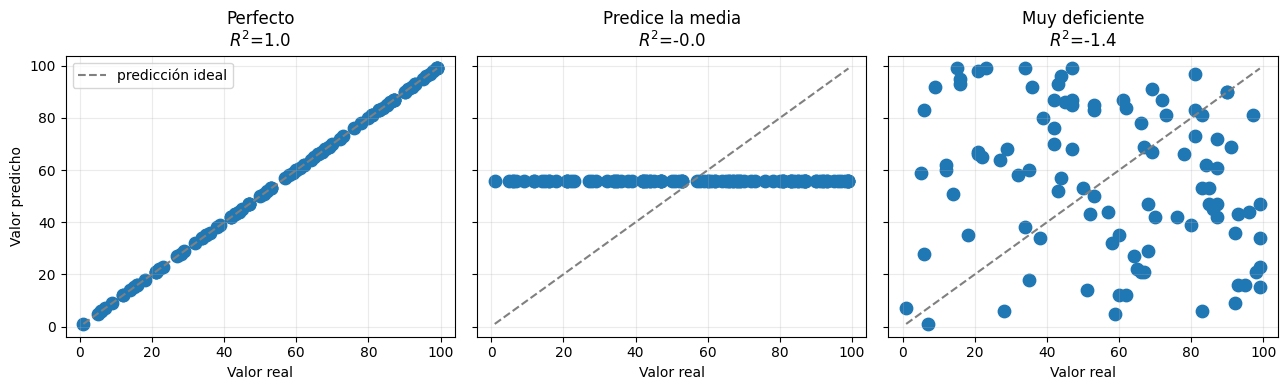

In [ ]:

x = np.random.randint(1, 101, size=100)
y_real = x 

mean = np.mean(x)

predicciones_r2 = {
    "Perfecto": x,
    "Predice la media": np.full_like(x, mean),
    "Muy deficiente": x[::-1],
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)

# Calculamos los límites para la línea ideal dinámicamente
min_val, max_val = x.min(), x.max() 

for ax, (nombre, y_pred) in zip(axes, predicciones_r2.items()):
    valor_r2 = r2_score(y_real, y_pred)
    print(nombre, valor_r2)
    ax.scatter(y_real, y_pred, s=80)
    
    # Línea ideal ajustada al nuevo rango
    ax.plot([min_val, max_val], [min_val, max_val], "--", color="gray", label="predicción ideal") 
    
    ax.set_title(f"{nombre}\n$R^2$={valor_r2:.1f}")
    ax.set_xlabel("Valor real")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Valor predicho")
axes[0].legend()
plt.tight_layout()
plt.show()

In [16]:
# 1. Entropía base (H)
def entropia(probabilidades):
    # Filtramos probabilidades mayores a 0 para evitar log2(0)
    p = probabilidades[probabilidades > 0]
    return -np.sum(p * np.log2(p))

# 2. Entropía Condicional H(Y|X)
def entropia_condicional(y, x):
    tabla = pd.crosstab(x, y, normalize=True)
    px = tabla.sum(axis=1)
    return sum(px.loc[v] * entropia(tabla.loc[v].to_numpy() / px.loc[v]) 
               for v in tabla.index if px.loc[v] > 0)

# 3. Entropía Conjunta H(X,Y)
def entropia_conjunta(x, y):
    # Calculamos la entropía sobre todas las celdas de la matriz conjunta
    tabla = pd.crosstab(x, y, normalize=True).to_numpy().flatten()
    return entropia(tabla)

proporciones = y_train.value_counts(normalize=True).to_numpy()
print(f"Proporciones de clases: {proporciones}")
print(f"Entropía del objetivo: {entropia(proporciones):.4f} bits")

Proporciones de clases: [0.62637363 0.37362637]
Entropía del objetivo: 0.9534 bits


--- X determina Y ---
H(Y|X) = 0.0 bits
H(X,Y) = 1.0 bits

--- X e Y independientes ---
H(Y|X) = 1.0 bits
H(X,Y) = 2.0 bits



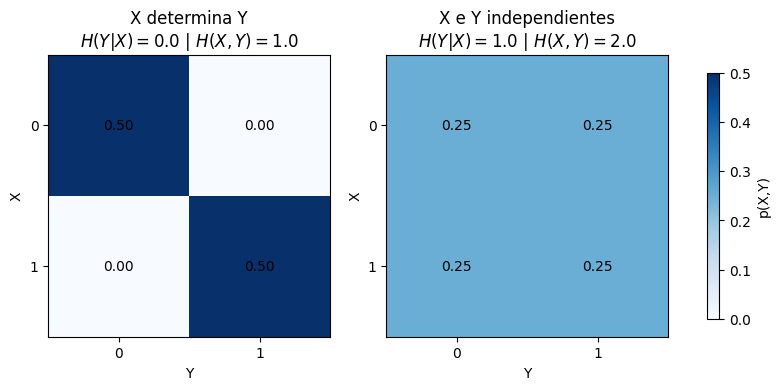

In [17]:
# --- Datos ---
X_ej = np.array([0, 0, 1, 1])
Y_ej = np.array([0, 0, 1, 1])

X_ind = np.array([0, 0, 1, 1])
Y_ind = np.array([0, 1, 0, 1])

# --- Gráficos y Resultados ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
casos = [
    (axes[0], "X determina Y", X_ej, Y_ej),
    (axes[1], "X e Y independientes", X_ind, Y_ind),
]

for ax, titulo, x_caso, y_caso in casos:
    h_condicional = entropia_condicional(y_caso, x_caso)
    h_conjunta = entropia_conjunta(x_caso, y_caso)
    
    # Imprimimos en consola
    print(f"--- {titulo} ---")
    print(f"H(Y|X) = {h_condicional:.1f} bits")
    print(f"H(X,Y) = {h_conjunta:.1f} bits\n")
    
    conjunta = pd.crosstab(x_caso, y_caso, normalize=True)
    imagen = ax.imshow(conjunta, cmap="Blues", vmin=0, vmax=0.5)
    
    for i in range(conjunta.shape[0]):
        for j in range(conjunta.shape[1]):
            ax.text(j, i, f"{conjunta.iloc[i, j]:.2f}", ha="center", va="center")
            
    # Agregamos las métricas al título para verlas en la imagen
    ax.set_title(f"{titulo}\n$H(Y|X)={h_condicional:.1f}$ | $H(X,Y)={h_conjunta:.1f}$")
    ax.set_xlabel("Y")
    ax.set_ylabel("X")
    ax.set_xticks(range(conjunta.shape[1]), conjunta.columns)
    ax.set_yticks(range(conjunta.shape[0]), conjunta.index)

fig.colorbar(imagen, ax=axes, label="p(X,Y)", shrink=0.8)
plt.show()


In [ ]:
from sklearn.metrics import mutual_info_score

x_mi = np.array([0, 0, 1, 1])
y_igual = np.array([0, 0, 1, 1])
y_independiente = np.array([0, 1, 0, 1])

# mutual_info_score usa logaritmo natural: el resultado se convierte a bits.
print("Dependencia perfecta:",
      mutual_info_score(x_mi, y_igual) / np.log(2), "bits")
print("Independencia:",
      mutual_info_score(x_mi, y_independiente) / np.log(2), "bits")

# Comparación visual: dependencia perfecta, independencia y dependencia no lineal.
rng_mi = np.random.default_rng(7)
x_curva = np.linspace(-2, 2, 200)
y_curva = x_curva**2 + rng_mi.normal(0, 0.12, size=x_curva.size)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(x_mi, y_igual, s=80)
axes[0].set_title("Dependencia perfecta\nI=1 bit")
axes[1].scatter(x_mi, y_independiente, s=80)
axes[1].set_title("Independencia\nI=0 bits")
axes[2].scatter(x_curva, y_curva, s=14, alpha=0.7)
axes[2].set_title("Dependencia no lineal\nPearson ≈ 0; MI > 0")
for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Dependencia perfecta: 1.0 bits
Independencia: 0.0 bits


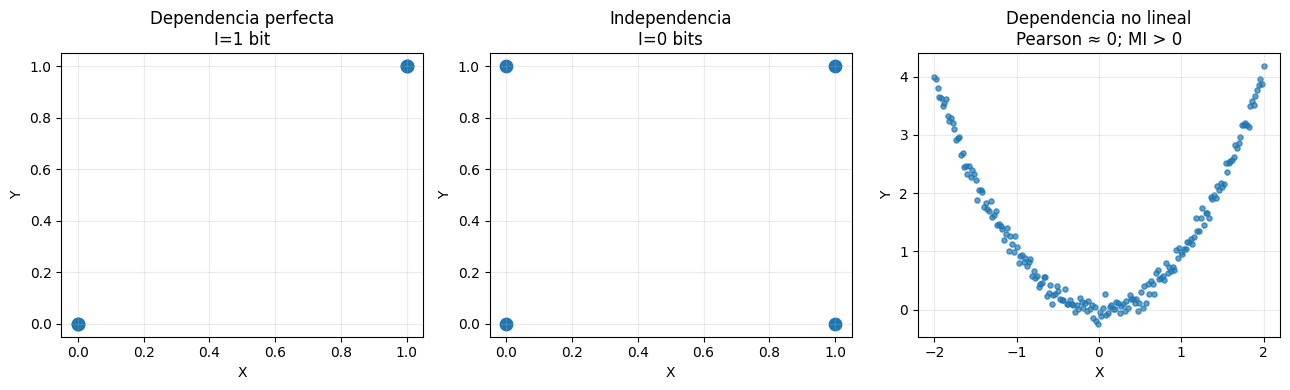

In [18]:
from sklearn.metrics import mutual_info_score

x_mi = np.array([0, 0, 1, 1])
y_igual = np.array([0, 0, 1, 1])
y_independiente = np.array([0, 1, 0, 1])

# mutual_info_score usa logaritmo natural: el resultado se convierte a bits.
print("Dependencia perfecta:",
      mutual_info_score(x_mi, y_igual) / np.log(2), "bits")
print("Independencia:",
      mutual_info_score(x_mi, y_independiente) / np.log(2), "bits")

# Comparación visual: dependencia perfecta, independencia y dependencia no lineal.
rng_mi = np.random.default_rng(7)
x_curva = np.linspace(-2, 2, 200)
y_curva = x_curva**2 + rng_mi.normal(0, 0.12, size=x_curva.size)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(x_mi, y_igual, s=80)
axes[0].set_title("Dependencia perfecta\nI=1 bit")
axes[1].scatter(x_mi, y_independiente, s=80)
axes[1].set_title("Independencia\nI=0 bits")
axes[2].scatter(x_curva, y_curva, s=14, alpha=0.7)
axes[2].set_title("Dependencia no lineal\nPearson ≈ 0; MI > 0")
for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


util          0.475073
copia_util    0.523483
ruido         0.001444
constante     0.000000
dtype: float64


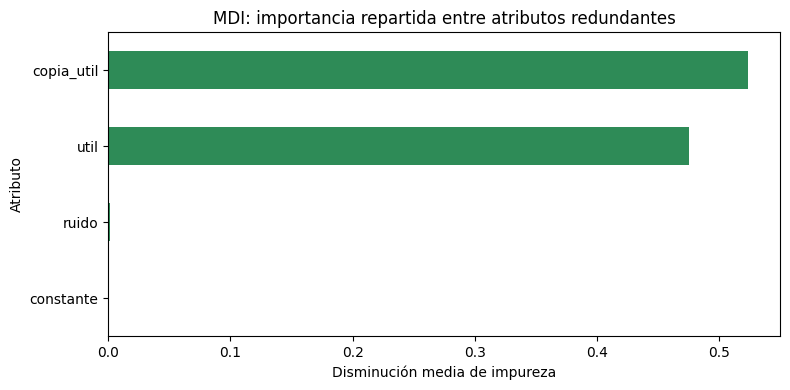

In [19]:
rng = np.random.default_rng(42)
n = 1000
x_util = rng.normal(size=n)
y_demo = (x_util > 0).astype(int)
X_demo = pd.DataFrame({
    "util": x_util,
    "copia_util": x_util,
    "ruido": rng.normal(size=n),
    "constante": 1,
})

rf_demo = RandomForestClassifier(n_estimators=200, random_state=42)
rf_demo.fit(X_demo, y_demo)
mdi_demo = pd.Series(rf_demo.feature_importances_, index=X_demo.columns)
print(mdi_demo)

ax = mdi_demo.sort_values().plot.barh(figsize=(8, 4), color="seagreen")
ax.set_title("MDI: importancia repartida entre atributos redundantes")
ax.set_xlabel("Disminución media de impureza")
ax.set_ylabel("Atributo")
plt.tight_layout()
plt.show()
